In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("HR_comma_sep.csv")
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


# Data Quality Checking

In [2]:
df.isnull().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
sales                    0
salary                   0
dtype: int64

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [4]:
df.shape

(14999, 10)

In [5]:
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


# Performing EDA

In [6]:
corr=df.corr(numeric_only=True)
corr

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
satisfaction_level,1.000000,0.105021,-0.142970,-0.020048,-0.100866,0.058697,-0.388375,0.025605
last_evaluation,0.105021,1.000000,0.349333,0.339742,0.131591,-0.007104,0.006567,-0.008684
number_project,-0.142970,0.349333,1.000000,0.417211,0.196786,-0.004741,0.023787,-0.006064
average_montly_hours,-0.020048,0.339742,0.417211,1.000000,0.127755,-0.010143,0.071287,-0.003544
time_spend_company,-0.100866,0.131591,0.196786,0.127755,1.000000,0.002120,0.144822,0.067433
Work_accident,0.058697,-0.007104,-0.004741,-0.010143,0.002120,1.000000,-0.154622,0.039245
left,-0.388375,0.006567,0.023787,0.071287,0.144822,-0.154622,1.000000,-0.061788
promotion_last_5years,0.025605,-0.008684,-0.006064,-0.003544,0.067433,0.039245,-0.061788,1.000000


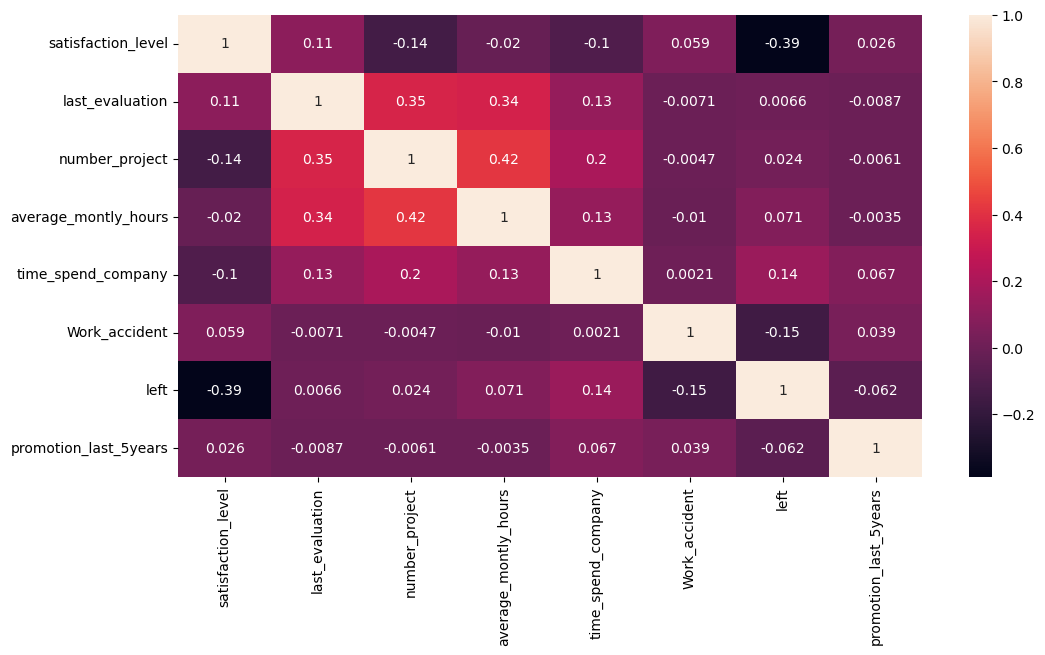

In [7]:
plt.figure(figsize=(12,6))
sns.heatmap(corr,annot=True)
plt.show()

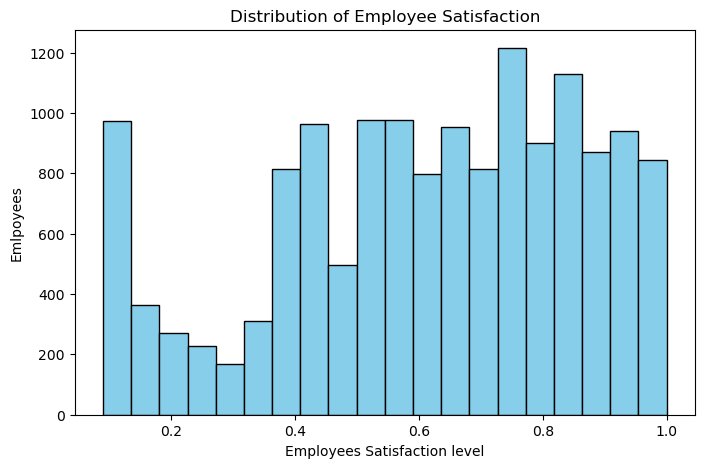

In [8]:
plt.figure(figsize=(8,5))
plt.hist(df["satisfaction_level"],bins=20,color="skyblue",edgecolor="black")
plt.xlabel("Employees Satisfaction level")
plt.ylabel("Emlpoyees")
plt.title("Distribution of Employee Satisfaction")
plt.show()

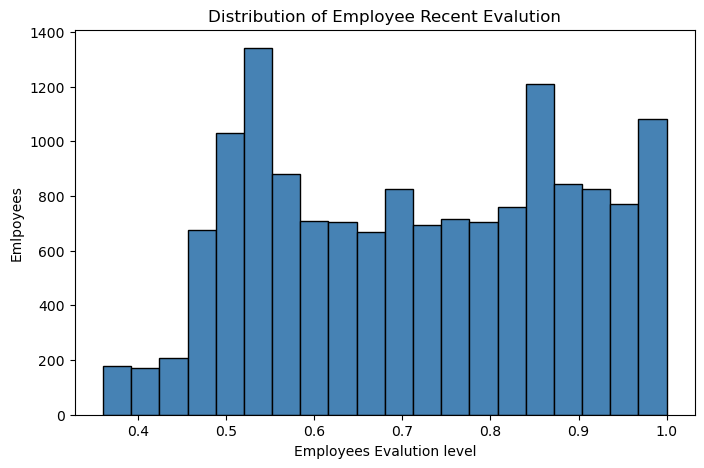

In [9]:
plt.figure(figsize=(8,5))
plt.hist(df["last_evaluation"],bins=20,color="steelblue",edgecolor="black")
plt.xlabel("Employees Evalution level")
plt.ylabel("Emlpoyees")
plt.title("Distribution of Employee Recent Evalution")
plt.show()

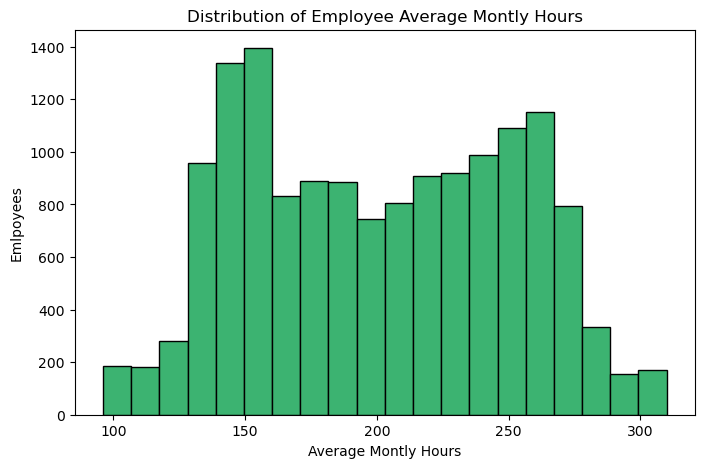

In [10]:
plt.figure(figsize=(8,5))
plt.hist(df["average_montly_hours"],bins=20,color="mediumseagreen",edgecolor="black")
plt.xlabel("Average Montly Hours")
plt.ylabel("Emlpoyees")
plt.title("Distribution of Employee Average Montly Hours")
plt.show()

In [10]:
employees_left=pd.crosstab(df["number_project"],df["left"])
employees_left=pd.DataFrame(employees_left)
employees_left.columns=["Stayed(0)" ,"left(1)"]
employees_left

,Stayed(0),left(1)
number_project,,
2,821,1567
3,3983,72
4,3956,409
5,2149,612
6,519,655
7,0,256


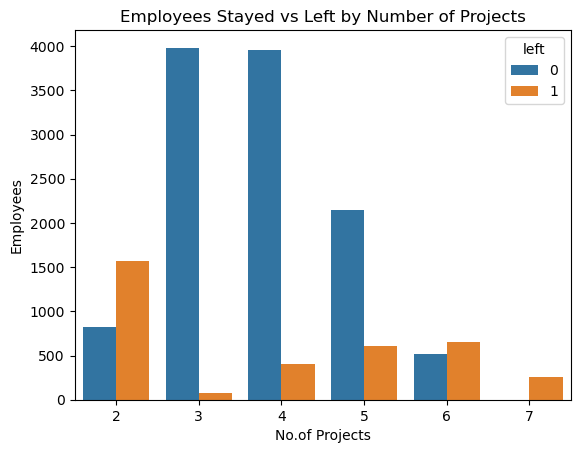

In [11]:
sns.countplot(x="number_project", hue="left", data=df)
plt.xlabel("No.of Projects")
plt.ylabel("Employees")
plt.title("Employees Stayed vs Left by Number of Projects")
plt.show()

In [12]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler
scaler=StandardScaler()
df["average_montly_hours"]=scaler.fit_transform(df[["average_montly_hours"]])

# k-Means clustering model

In [13]:
from sklearn.cluster import KMeans
x=df[["satisfaction_level","last_evaluation","left"]].values
model=KMeans(n_clusters=3, n_init=10, init="k-means++", random_state=42)
y_kmeans=model.fit_predict(x)

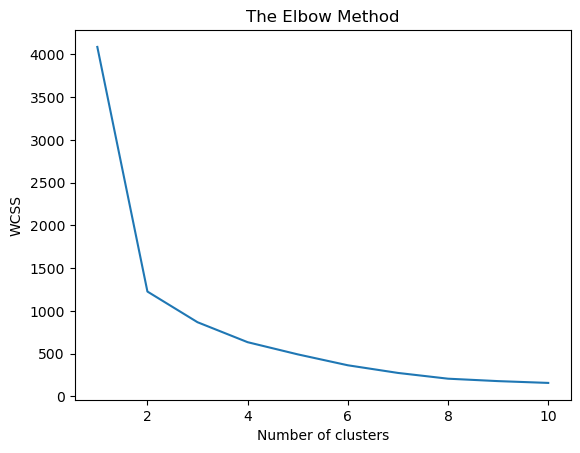

In [14]:
wcss=[]
for i in range(1,11):
    model=KMeans(n_clusters=i, n_init=10, init="k-means++", random_state=42)
    res=model.fit(x)
    wcss.append(res.inertia_)
plt.plot(range(1,11),wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

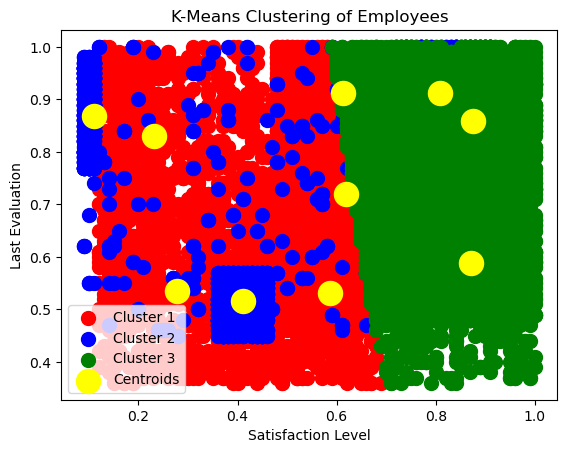

In [15]:
plt.scatter(x[y_kmeans == 0, 0],x[y_kmeans == 0, 1],s=100,c='red',label='Cluster 1')
plt.scatter(x[y_kmeans == 1, 0], x[y_kmeans == 1, 1], s = 100, c = 'blue', label = 'Cluster 2')
plt.scatter(x[y_kmeans == 2, 0], x[y_kmeans == 2, 1], s = 100, c = 'green', label = 'Cluster 3')
plt.scatter(model.cluster_centers_[:, 0], model.cluster_centers_[:, 1], s = 300, c = 'yellow', label = 'Centroids')
plt.xlabel("Satisfaction Level")
plt.ylabel("Last Evaluation")
plt.title("K-Means Clustering of Employees")
plt.legend()
plt.show()
plt.show()

In [16]:
from sklearn.metrics import silhouette_score
score=silhouette_score(x,y_kmeans)
print(score)

0.4339269204075329


In [17]:
df["cluster"] = y_kmeans
df.groupby("cluster")[["satisfaction_level", "last_evaluation"]].mean()

,satisfaction_level,last_evaluation
cluster,,
0,0.458195,0.681224
1,0.440098,0.718113
2,0.813334,0.739529


In [18]:
new_employee = [[0.75, 0.80, 0]]
clus=model.predict(new_employee)
print(clus)

[5]


# Data Preprocessing and Class Imbalance Handling

In [19]:
numerical_col=df.drop(["sales","salary"],axis=1)
category_col=df[["sales","salary"]]

In [20]:
dummies=pd.get_dummies(category_col, drop_first=True).astype(int)
dummies.head()

,sales_RandD,sales_accounting,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,salary_low,salary_medium
0,0,0,0,0,0,0,1,0,0,1,0
1,0,0,0,0,0,0,1,0,0,0,1
2,0,0,0,0,0,0,1,0,0,0,1
3,0,0,0,0,0,0,1,0,0,1,0
4,0,0,0,0,0,0,1,0,0,1,0


In [21]:
numeric_data=pd.concat([numerical_col,dummies],axis=1)
numeric_data.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,cluster,sales_RandD,sales_accounting,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,salary_low,salary_medium
0,0.38,0.53,2,-0.882040,3,0,1,0,1,0,0,0,0,0,0,1,0,0,1,0
1,0.80,0.86,5,1.220423,6,0,1,0,1,0,0,0,0,0,0,1,0,0,0,1
2,0.11,0.88,7,1.420657,4,0,1,0,1,0,0,0,0,0,0,1,0,0,0,1
3,0.72,0.87,5,0.439508,5,0,1,0,1,0,0,0,0,0,0,1,0,0,1,0
4,0.37,0.52,2,-0.841993,3,0,1,0,1,0,0,0,0,0,0,1,0,0,1,0


In [22]:
numeric_data=numeric_data.drop("cluster",axis=1)
x=numeric_data.drop("left",axis=1)
y=numeric_data["left"]

In [26]:
from sklearn.model_selection import train_test_split, cross_val_score,StratifiedKFold
st=StratifiedKFold(n_splits=10, random_state=123, shuffle=True)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=123,stratify=y)

In [25]:
from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=132)
x_train_smote,y_train_smote=smote.fit_resample(x_train,y_train)

In [26]:
y_train.value_counts()

left
0    9142
1    2857
Name: count, dtype: int64

In [27]:
y_train_smote.value_counts()

left
0    9142
1    9142
Name: count, dtype: int64

#LogisticRegression Model

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,ConfusionMatrixDisplay
log_reg=LogisticRegression()
log_reg.fit(x_train_smote,y_train_smote)

LogisticRegression()

In [29]:
cross_score=cross_val_score(log_reg,x_train_smote,y_train_smote,cv=5,scoring="accuracy")

In [30]:
cross_score.mean()

np.float64(0.7770185352392133)

In [31]:
log_reg_y_train_smote_pred = log_reg.predict(x_train_smote)
log_reg_y_test_pred = log_reg.predict(x_test)
log_reg_y_train_smote_pred_accur_score = accuracy_score(y_train_smote,log_reg_y_train_smote_pred)
log_reg_y_test_pred_accur_score = accuracy_score(y_test,log_reg_y_test_pred)
print(log_reg_y_train_smote_pred_accur_score)
print(log_reg_y_test_pred_accur_score)

0.7780026252461169
0.7673333333333333


[[1726  560]
 [ 138  576]]


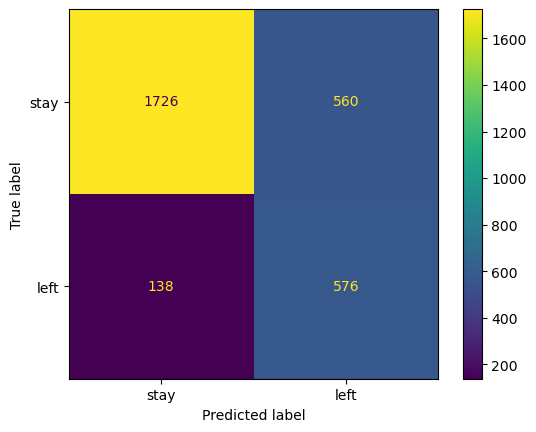

In [32]:
log_reg_conf_matrix=confusion_matrix(y_test,log_reg_y_test_pred)
print(log_reg_conf_matrix)
conf_display=ConfusionMatrixDisplay(log_reg_conf_matrix,display_labels=["stay","left"])
conf_display.plot()

In [33]:
print("\t\tLogistic Regression Classification Report:")
print(classification_report(y_test, log_reg_y_test_pred))

		Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.76      0.83      2286
           1       0.51      0.81      0.62       714

    accuracy                           0.77      3000
   macro avg       0.72      0.78      0.73      3000
weighted avg       0.83      0.77      0.78      3000



In [34]:
log_reg_prob=log_reg.predict_proba(x_test)[:,1]
log_reg_df=pd.DataFrame({"actual_values":y_test,
                    "pred_values":log_reg_y_test_pred,
                    "probability":log_reg_prob
                   })
log_reg_df.head()

,actual_values,pred_values,probability
10627,0,0,0.078950
2703,0,1,0.826821
6059,0,0,0.491286
3258,0,0,0.180691
4565,0,0,0.342934


Text(0.5, 1.0, 'Roc-Auc curve for Logistic Regression')

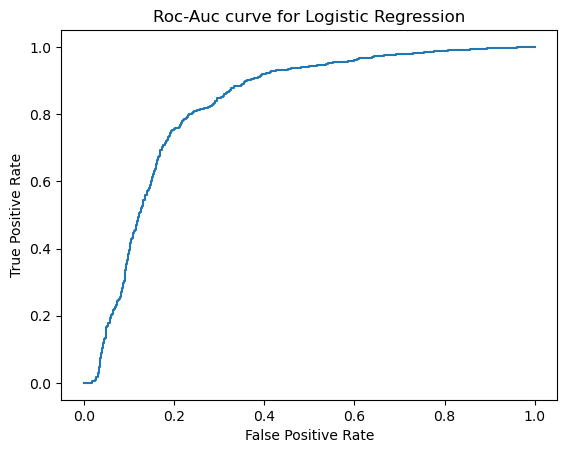

In [35]:
from sklearn.metrics import roc_curve,auc
fpr, tpr, thresholds = roc_curve(y_test,log_reg_prob )
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Roc-Auc curve for Logistic Regression")

# RandomForestClassifier Model

In [36]:
from sklearn.ensemble import RandomForestClassifier
RFC_model= RandomForestClassifier(n_estimators=100)
CV_score=cross_val_score(RFC_model, x_train_smote,y_train_smote,cv=5, scoring="accuracy")

In [37]:
CV_score.mean()

np.float64(0.9838109402010113)

In [38]:
RFC_model.fit(x_train_smote,y_train_smote)

RandomForestClassifier()

In [39]:
rfc_y_train_smote_pred=RFC_model.predict(x_train_smote)
rfc_y_test_pred=RFC_model.predict(x_test)
rfc_y_train_smote_acc_score=accuracy_score(y_train_smote, rfc_y_train_smote_pred)
rfc_y_test_acc_score=accuracy_score(y_test, rfc_y_test_pred)
print(rfc_y_train_smote_acc_score)
print(rfc_y_test_acc_score)

1.0
0.9903333333333333


[[2271   15]
 [  14  700]]


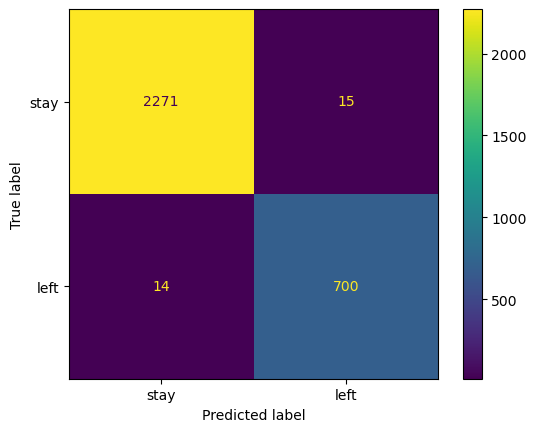

In [40]:
rfc_conf_matrix=confusion_matrix(y_test,rfc_y_test_pred)
conf_display=ConfusionMatrixDisplay(rfc_conf_matrix,display_labels=["stay","left"])
conf_display.plot()
print(rfc_conf_matrix)

In [41]:
rfc_cls_report=classification_report(y_test, rfc_y_test_pred)
print(rfc_cls_report)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2286
           1       0.98      0.98      0.98       714

    accuracy                           0.99      3000
   macro avg       0.99      0.99      0.99      3000
weighted avg       0.99      0.99      0.99      3000



In [43]:
rfc_prob=RFC_model.predict_proba(x_test)[:,1]
rfc_prob = RFC_model.predict_proba(x_test)[:,1]
rfc_df=pd.DataFrame({"actual_values":y_test,
                    "pred_values":rfc_y_test_pred,
                    "probability":rfc_prob
                   })
rfc_df.head()

,actual_values,pred_values,probability
10627,0,0,0.00
2703,0,1,0.60
6059,0,0,0.03
3258,0,0,0.01
4565,0,0,0.00


Text(0.5, 1.0, 'Roc-Auc curve for Random Fore Classifier')

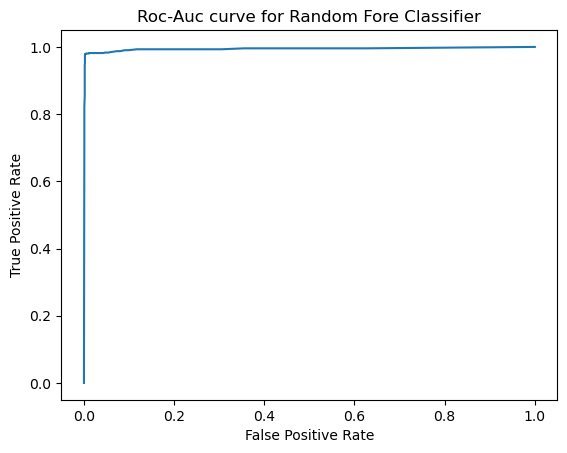

In [44]:
from sklearn.metrics import roc_curve,auc
fpr, tpr, thresholds = roc_curve(y_test,rfc_prob )
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Roc-Auc curve for Random Fore Classifier")

# GradientBoostingClassifier Model

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
GB_model=GradientBoostingClassifier(n_estimators=100, random_state=7)
GB_CV_score=cross_val_score(GB_model,x_train_smote,y_train_smote,cv=5,scoring="accuracy")
GB_CV_score

In [ ]:
GB_CV_score.mean()

In [ ]:
GB_model.fit(x_train_smote,y_train_smote)

In [ ]:
gb_y_train_smote_pred=GB_model.predict(x_train_smote)
gb_y_test=GB_model.predict(x_test)
gb_y_train_acc_score=accuracy_score(y_train_smote,gb_y_train_smote_pred)
gb_y_test_acc_score=accuracy_score(y_test, gb_y_test)
print(gb_y_train_acc_score)
print(gb_y_test_acc_score)

In [ ]:
gb_conf_matrix=confusion_matrix(y_test,gb_y_test)
conf_display=ConfusionMatrixDisplay(gb_conf_matrix,display_labels=["stay","left"])
conf_display.plot()
print(gb_conf_matrix)

In [ ]:
GB_cls_report=classification_report(y_test, gb_y_test)
print(GB_cls_report)

In [ ]:
gb_prob = GB_model.predict_proba(x_test)[:,1]
gb_df=pd.DataFrame({"actual_values":y_test,
                    "pred_values":gb_y_test,
                    "probability":gb_prob
                   })
gb_df.head()

In [ ]:
from sklearn.metrics import roc_curve,auc
fpr, tpr, thresholds = roc_curve(y_test,gb_prob )
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Roc-Auc curve for Gradient Boosting Classifier")

# Best Model for Employee Turnover Predictions.

In [ ]:
results = pd.DataFrame({
    "Employee_ID": x_test.index,
    "Turnover_Probability": rfc_prob
})

results.head()

In [ ]:
def risk_zone(prob):
    
    if prob < 0.20:
        return "Safe Zone (Green)"
    
    elif prob < 0.60:
        return "Low-Risk Zone (Yellow)"
    
    elif prob < 0.90:
        return "Medium-Risk Zone (Orange)"
    
    else:
        return "High-Risk Zone (Red)"

results["Risk_Zone"] = results[
    "Turnover_Probability"
].apply(risk_zone)

results.head()